In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
data = pd.read_csv("..Dataset/loan_prediction.csv")

In [4]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [6]:
data.shape

(614, 13)

In [7]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [8]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


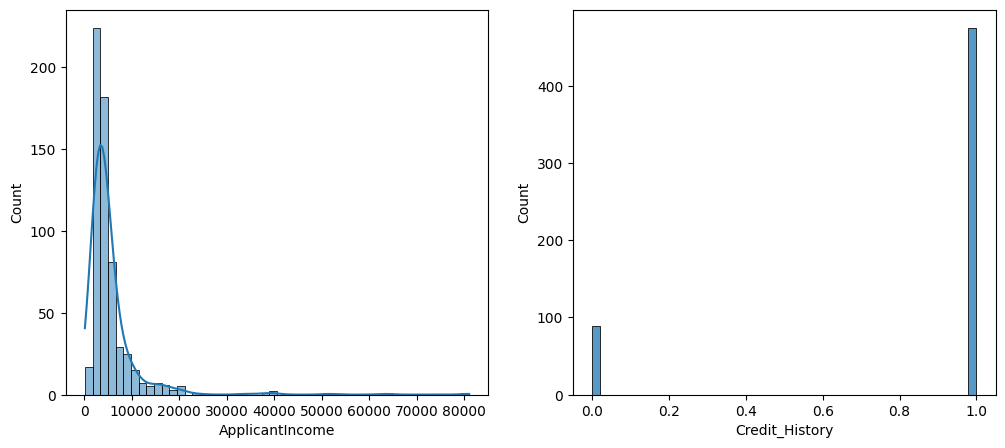

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(data["ApplicantIncome"], kde=True)

plt.subplot(122)
sns.histplot(data["Credit_History"])

plt.show()

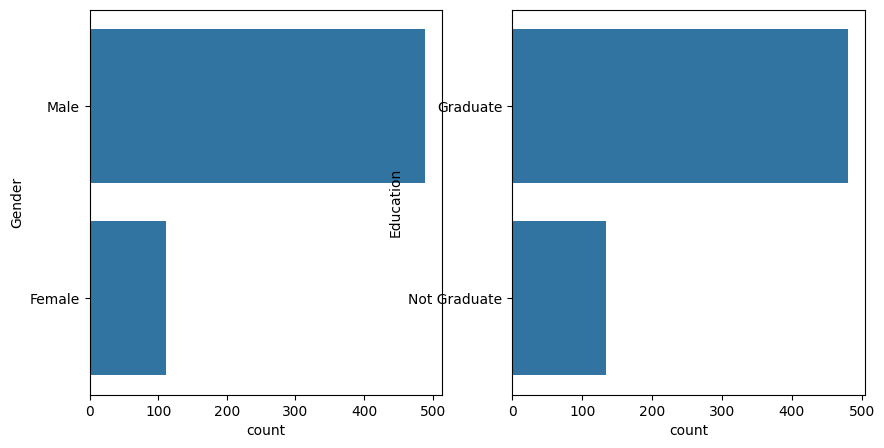

In [11]:
plt.figure(figsize=(10,5))

plt.subplot(121)
sns.countplot(y=data["Gender"])

plt.subplot(122)
sns.countplot(y=data["Education"])

plt.show()

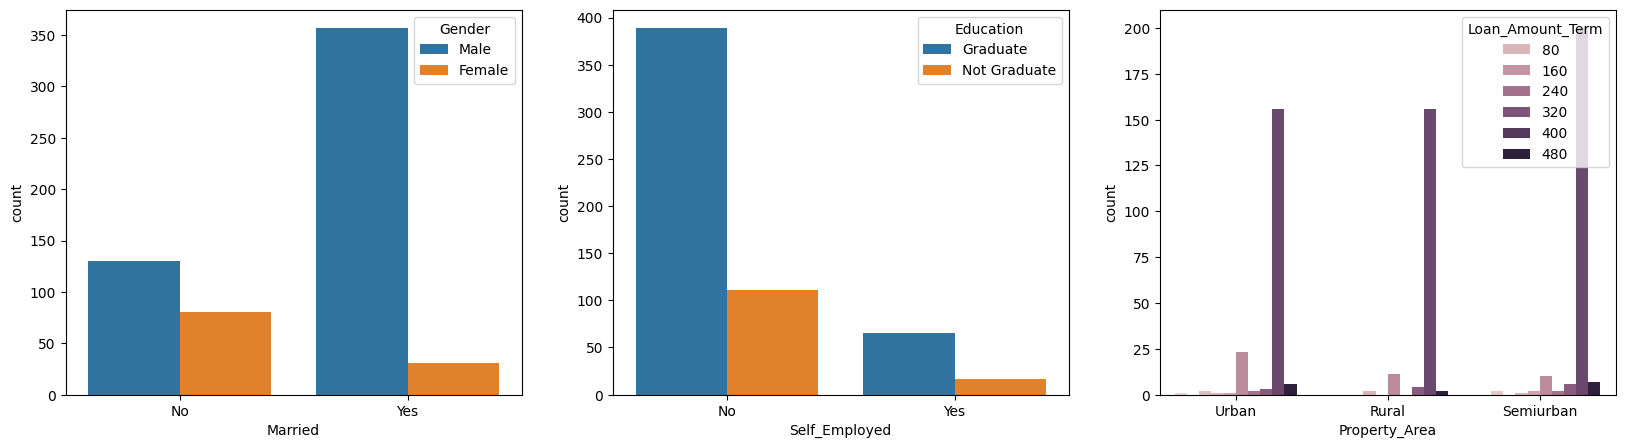

In [12]:
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(x="Married", hue="Gender", data=data)

plt.subplot(132)
sns.countplot(x="Self_Employed", hue="Education", data=data)

plt.subplot(133)
sns.countplot(x="Property_Area", hue="Loan_Amount_Term", data=data)

plt.show()

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 61.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


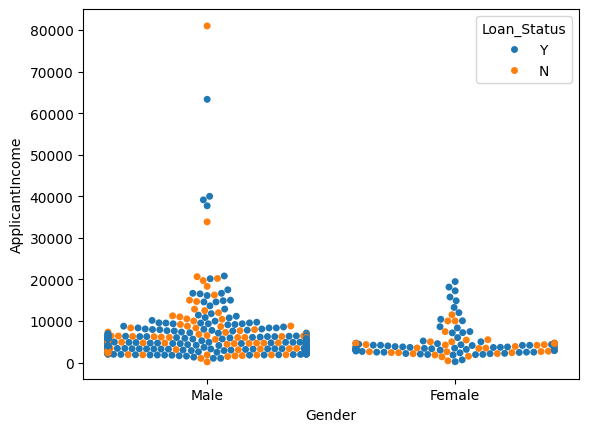

In [13]:
sns.swarmplot(
    x="Gender",
    y="ApplicantIncome",
    hue="Loan_Status",
    data=data
)

plt.show()

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode().iloc[0])

data['Married'] = data['Married'].fillna(data['Married'].mode().iloc[0])

data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode().iloc[0])

data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode().iloc[0])

data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode().iloc[0])

data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode().iloc[0])

In [16]:
data['Dependents'] = data['Dependents'].replace('3+', 3)

In [17]:
data['Gender'] = data['Gender'].map({'Male':0,'Female':1})

data['Married'] = data['Married'].map({'No':0,'Yes':1})

data['Education'] = data['Education'].map({'Not Graduate':0,'Graduate':1})

data['Self_Employed'] = data['Self_Employed'].map({'No':0,'Yes':1})

data['Property_Area'] = data['Property_Area'].map({'Rural':0,'Semiurban':1,'Urban':2})

data['Loan_Status'] = data['Loan_Status'].map({'N':0,'Y':1})

In [18]:
data['Dependents'] = data['Dependents'].astype(int)

data['LoanAmount'] = data['LoanAmount'].astype(int)

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype(int)

data['Credit_History'] = data['Credit_History'].astype(int)

In [19]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [20]:
X = data.drop(['Loan_ID','Loan_Status'], axis=1)

y = data['Loan_Status']

In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
sm = SMOTE(random_state=42)

X, y = sm.fit_resample(X, y)

In [28]:
print(y.value_counts())

Loan_Status
1    422
0    422
Name: count, dtype: int64


In [32]:
names = X.columns

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
sc = StandardScaler()

X = sc.fit_transform(X)

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

In [41]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(565, 11)
(279, 11)
(565,)
(279,)


In [42]:
import pandas as pd
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
import pickle

In [44]:
def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cv = cross_val_score(model, X_train, y_train, cv=5)
    print("\nCross Validation Accuracy:", cv.mean())

    return model

dt_model = decisionTree(X_train, X_test, y_train, y_test)

Decision Tree Accuracy: 0.7706093189964157

Confusion Matrix
[[106  42]
 [ 22 109]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       148
           1       0.72      0.83      0.77       131

    accuracy                           0.77       279
   macro avg       0.77      0.77      0.77       279
weighted avg       0.78      0.77      0.77       279


Cross Validation Accuracy: 0.7486725663716813


In [45]:
def randomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cv = cross_val_score(model, X_train, y_train, cv=5)
    print("\nCross Validation Accuracy:", cv.mean())

    return model

rf_model = randomForest(X_train, X_test, y_train, y_test)

Random Forest Accuracy: 0.8136200716845878

Confusion Matrix
[[111  37]
 [ 15 116]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       148
           1       0.76      0.89      0.82       131

    accuracy                           0.81       279
   macro avg       0.82      0.82      0.81       279
weighted avg       0.82      0.81      0.81       279


Cross Validation Accuracy: 0.831858407079646


In [46]:
def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("KNN Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cv = cross_val_score(model, X_train, y_train, cv=5)
    print("\nCross Validation Accuracy:", cv.mean())

    return model

knn_model = KNN(X_train, X_test, y_train, y_test)

KNN Accuracy: 0.7491039426523297

Confusion Matrix
[[100  48]
 [ 22 109]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       148
           1       0.69      0.83      0.76       131

    accuracy                           0.75       279
   macro avg       0.76      0.75      0.75       279
weighted avg       0.76      0.75      0.75       279


Cross Validation Accuracy: 0.784070796460177


In [47]:
def xgboost(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cv = cross_val_score(model, X_train, y_train, cv=5)
    print("\nCross Validation Accuracy:", cv.mean())

    return model

gb_model = xgboost(X_train, X_test, y_train, y_test)

Gradient Boosting Accuracy: 0.7921146953405018

Confusion Matrix
[[102  46]
 [ 12 119]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.69      0.78       148
           1       0.72      0.91      0.80       131

    accuracy                           0.79       279
   macro avg       0.81      0.80      0.79       279
weighted avg       0.81      0.79      0.79       279


Cross Validation Accuracy: 0.8176991150442477


In [48]:
pickle.dump(rf_model, open("rdf.pkl", "wb"))

In [49]:
pickle.dump(dt_model, open("dt.pkl", "wb"))

In [50]:
pickle.dump(knn_model, open("knn.pkl", "wb"))

In [51]:
pickle.dump(gb_model, open("gb.pkl", "wb"))